# Random Forest: Feature Set 1 (2026-10-04)

Feature set 1 is the R score only (`cote_r_equivalent`). The other feature sets are listed in section 1.

Fairness is measured between two groups: **Centre** (Montreal, Capitale-Nationale) vs **Remote** (Bas-Saint-Laurent, Cote-Nord, Gaspesie-Iles-de-la-Madeleine).

## Overview

```
10,000 labeled rows
        ↓
Split:
8,000 train
2,000 validation
        ↓
ON THE 8,000:

Try 20 hyperparameter settings
        ↓
For EACH setting:
5-fold CV
        ↓
Average CV score
        ↓
Choose best hyperparameters
        ↓
Refit best base model on all 8,000
        ↓
Freeze base model
        ↓
ON THE 2,000:

FAIRNESS SWEEP

tol = 0.00
tol = 0.02
tol = 0.05
tol = 0.10
tol = 0.20

For EACH tol:
        ↓
ThresholdOptimizer
Demographic Parity
Centre vs Remote
        ↓
Get fairness-adjusted score / selection probability
        ↓
ENFORCE BUDGET:
rank using that fair score
        ↓
TOP 40% = 1
BOTTOM 60% = 0
        ↓
Now measure FINAL:
• accuracy vs committee
• demographic-parity gap (Centre vs Remote)
• grant rate = exactly 40%
        ↓
Each tol = one Pareto point
        ↓
Plot:
x = fairness gap (Centre vs Remote)
y = accuracy
        ↓
Choose best tol
        ↓
Final configuration fixed:
• model
• feature set
• hyperparameters
• tol
        ↓
Apply configuration to 4,000
        ↓
Fairness adjustment
using chosen tol
        ↓
Rank by fair score
        ↓
TOP 1,600 = 1
BOTTOM 2,400 = 0
        ↓
predictions.csv
        ↓
SUBMIT
```

## 1. 10,000 labeled rows: split into 8,000 train and 2,000 validation

The split is stratified on the label and the Centre/Remote group together.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.metrics import demographic_parity_difference
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

FEATURE_SET = 1
FEATURE_SETS = {
    1: ["cote_r_equivalent"],
    2: ["cote_r_equivalent", "revenu_familial_estime", "heures_travail_semaine"],
    3: ["cote_r_equivalent", "revenu_familial_estime", "heures_travail_semaine",
        "programme_etudes", "premiere_generation_universitaire"],
}
CATEGORICAL = ["programme_etudes"]
TOL_VALUES = [0.0, 0.02, 0.05, 0.10, 0.20]   # 0.0 = strictest (no relaxation)
BUDGET, N_SETTINGS, N_FOLDS, SEED = 0.40, 20, 5, 42
REMOTE = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}

# Data is in equialgo-participants/data. Walk up from this notebook until it is found.
data_dir = next(
    (p / "equialgo-participants" / "data" for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "equialgo-participants" / "data" / "donnees_demandes.csv").is_file()),
    None,
)
if data_dir is None:
    raise FileNotFoundError("Could not find equialgo-participants/data from " + str(Path.cwd()))
OUT_DIR = Path.cwd()   # outputs are saved next to this notebook, inside its feature_set folder
if Path.cwd().name.startswith("feature_set_") and Path.cwd().name != f"feature_set_{FEATURE_SET}":
    print(f"WARNING: running in '{Path.cwd().name}' but FEATURE_SET = {FEATURE_SET}")
print("Reading data from:", data_dir)
print("Saving outputs to:", OUT_DIR)
STEM = f"random_forest_feature_set_{FEATURE_SET}"   # same name as the notebook

df = pd.read_csv(data_dir / "donnees_demandes.csv")
cols = FEATURE_SETS[FEATURE_SET]
X, y = df[cols], df["decision_octroi"]
g = pd.Series(np.where(df["region_administrative"].isin(REMOTE), "Remote", "Centre"), index=df.index)

# Stratify on label AND region group, so both distributions are preserved in each split
strata = y.astype(str) + "_" + g
X_tr, X_val, y_tr, y_val, g_tr, g_val = train_test_split(
    X, y, g, test_size=0.20, random_state=SEED, stratify=strata
)
print(len(X_tr), "train rows,", len(X_val), "validation rows, features:", cols)
print(pd.DataFrame({
    "all": [y.mean(), (g == "Centre").mean(), (g == "Remote").mean()],
    "train": [y_tr.mean(), (g_tr == "Centre").mean(), (g_tr == "Remote").mean()],
    "validation": [y_val.mean(), (g_val == "Centre").mean(), (g_val == "Remote").mean()],
}, index=["grant rate", "Centre share", "Remote share"]).round(4))

Reading data from: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/equialgo-participants/data
Saving outputs to: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/models/random_forest/feature_set_1
8000 train rows, 2000 validation rows, features: ['cote_r_equivalent']
                 all   train  validation
grant rate    0.3994  0.3995       0.399
Centre share  0.6000  0.6000       0.600
Remote share  0.4000  0.4000       0.400


## 2. On the 8,000: try 20 hyperparameter settings

In [2]:
cats = [c for c in cols if c in CATEGORICAL]
nums = [c for c in cols if c not in CATEGORICAL]
parts = [("num", StandardScaler(), nums)]
if cats:
    parts.append(("cat", OneHotEncoder(handle_unknown="ignore"), cats))

pipe = Pipeline([
    ("prep", ColumnTransformer(parts)),
    ("clf", RandomForestClassifier(random_state=SEED, n_jobs=1)),
])
grid = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [4, 5, 6, 8],
    "clf__min_samples_leaf": [10, 20, 30],
}
search = RandomizedSearchCV(pipe, grid, n_iter=N_SETTINGS, cv=N_FOLDS, scoring="accuracy",
                            random_state=SEED, n_jobs=-1, refit=True)

## 3. For each setting: 5-fold CV, then the average CV score

In [3]:
search.fit(X_tr, y_tr)
cv = pd.DataFrame(search.cv_results_)
cv_table = cv[["param_clf__n_estimators", "param_clf__max_depth", "param_clf__min_samples_leaf",
               "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False)
print(cv_table.round(4).to_string(index=False))

 param_clf__n_estimators  param_clf__max_depth  param_clf__min_samples_leaf  mean_test_score  std_test_score
                     200                     4                           30           0.8575          0.0139
                     200                     4                           20           0.8572          0.0138
                     100                     4                           10           0.8570          0.0131
                     100                     5                           30           0.8569          0.0141
                     150                     4                           20           0.8569          0.0132
                     150                     4                           10           0.8568          0.0131
                     200                     5                           30           0.8568          0.0143
                     150                     5                           20           0.8567          0.0143
                   

## 4. Choose the best hyperparameters

In [4]:
print("Best settings:", search.best_params_)
print(f"Average CV accuracy: {search.best_score_:.4f}")

Best settings: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 30, 'clf__max_depth': 4}
Average CV accuracy: 0.8575


## 5. Refit the best base model on all 8,000, then freeze it

`best_estimator_` is already refit on the 8,000. It is not retrained after this.

In [5]:
base = search.best_estimator_
s_val = base.predict_proba(X_val)[:, 1].astype("float64")   # grant probability for each of the 2,000
print("Validation scores:", s_val.shape)

Validation scores: (2000,)


## 6. On the 2,000: fairness sweep

One pass per value in `TOL_VALUES` (0.00, 0.02, 0.05, 0.10, 0.20). The steps for each `tol` are in sections 7 to 9.

In [6]:
print("Sweep over tol =", TOL_VALUES)

Sweep over tol = [0.0, 0.02, 0.05, 0.1, 0.2]


## 7. For each tol: ThresholdOptimizer (demographic parity, Centre vs Remote)

`ThresholdOptimizer` is fitted on the 2,000 validation rows. It works on the frozen model's scores (a pass-through estimator), and returns the fairness-adjusted score (selection probability).

In [7]:
class ScoreEstimator(BaseEstimator, ClassifierMixin):
    """Treats the frozen model's score as the probability, so ThresholdOptimizer works on scores."""
    def fit(self, X=None, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        s = np.asarray(X, dtype="float64").reshape(-1)
        return np.c_[1 - s, s]


def fit_fairness(tol):
    to = ThresholdOptimizer(
        estimator=ScoreEstimator().fit(), constraints="demographic_parity",
        objective="accuracy_score", prefit=True, predict_method="predict_proba",
        tol=None if tol == 0 else tol,
    )
    return to.fit(s_val.reshape(-1, 1), y_val, sensitive_features=g_val)


def fair_score(to, scores, groups):
    """Fairness-adjusted selection probability for each applicant."""
    return to._pmf_predict(scores.reshape(-1, 1), sensitive_features=groups)[:, 1]

## 8. Enforce budget: rank by the fair score, top 40% = 1, bottom 60% = 0

Ties in the fair score are broken by the base model score.

In [8]:
def cut_budget(fair, base_score):
    k = int(BUDGET * len(fair))
    order = np.lexsort((-base_score, -fair))
    out = np.zeros(len(fair), dtype=int)
    out[order[:k]] = 1
    return out

## 9. Measure final: accuracy vs committee, demographic-parity gap (Centre vs Remote), grant rate

The first row is the plain top 40% with no fairness step, for reference.

In [9]:
def measure(pred):
    return {"parity_gap": demographic_parity_difference(y_val, pred, sensitive_features=g_val),
            "accuracy": (pred == y_val).mean(), "grant_rate": pred.mean()}


rows = [{"tol": "plain 40%", **measure(cut_budget(s_val, s_val))}]
for tol in TOL_VALUES:
    to = fit_fairness(tol)
    pred = cut_budget(fair_score(to, s_val, g_val), s_val)
    rows.append({"tol": tol, **measure(pred)})

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))
results.round(4).to_csv(OUT_DIR / f"{STEM}_pareto.csv", index=False)

if results["parity_gap"].iloc[1:].round(4).eq(results["parity_gap"].iloc[0].round(4)).all():
    print("\nNOTE: every tol gives the same gap as the plain 40% row. "
          "The budget cut is cancelling the fairness step.")

      tol  parity_gap  accuracy  grant_rate
plain 40%      0.0854     0.857         0.4
      0.0      0.0083     0.843         0.4
     0.02      0.0083     0.843         0.4
     0.05      0.0917     0.860         0.4
      0.1      0.1021     0.861         0.4
      0.2      0.1833     0.866         0.4


## 10. Each tol = one Pareto point

x = fairness gap between Centre and Remote (smaller is fairer), y = accuracy vs committee.

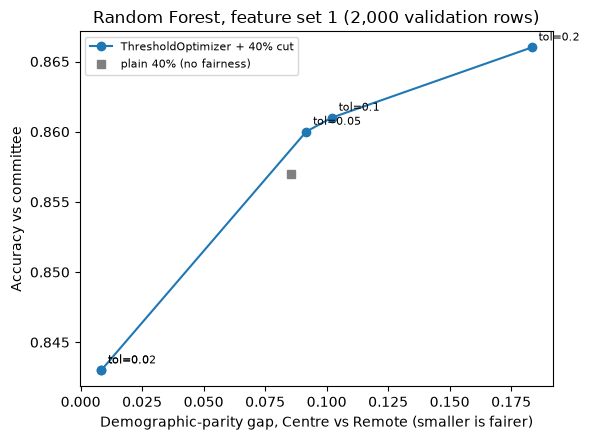

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sweep = results.iloc[1:]
ax.plot(sweep["parity_gap"], sweep["accuracy"], "o-", label="ThresholdOptimizer + 40% cut")
for _, r in sweep.iterrows():
    ax.annotate(f"tol={r['tol']}", (r["parity_gap"], r["accuracy"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.plot(results["parity_gap"].iloc[0], results["accuracy"].iloc[0], "s", color="gray",
        label="plain 40% (no fairness)")
ax.set_xlabel("Demographic-parity gap, Centre vs Remote (smaller is fairer)")
ax.set_ylabel("Accuracy vs committee")
ax.set_title(f"Random Forest, feature set {FEATURE_SET} (2,000 validation rows)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / f"{STEM}_pareto.png", dpi=150)
plt.show()

## 11. Choose the best tol

Pick one `tol` from the plot. Prefer a point where the gap has dropped a lot before accuracy falls fast.

In [15]:
CHOSEN_TOL = 0.02   # set to the tol you picked, for example 0.05

## 12. Final configuration fixed

Model, feature set, hyperparameters and tol.

In [16]:
final_config = {
    "model": "Random Forest",
    "feature_set": FEATURE_SET,
    "features": cols,
    "hyperparameters": search.best_params_,
    "tol": CHOSEN_TOL,
}
final_config

{'model': 'Random Forest',
 'feature_set': 1,
 'features': ['cote_r_equivalent'],
 'hyperparameters': {'clf__n_estimators': 200,
  'clf__min_samples_leaf': 30,
  'clf__max_depth': 4},
 'tol': 0.02}

## 13. Apply the configuration to the 4,000

Fairness adjustment with the chosen `tol`, rank by the fair score, top 1,600 = 1, bottom 2,400 = 0. It also prints the Centre vs Remote gap on the 4,000 themselves, which needs no labels.

In [17]:
if CHOSEN_TOL is None:
    print("Set CHOSEN_TOL in section 11 first.")
else:
    cand = pd.read_csv(data_dir / "candidats_evaluation.csv")
    g_cand = pd.Series(np.where(cand["region_administrative"].isin(REMOTE), "Remote", "Centre"),
                       index=cand.index)
    s_cand = base.predict_proba(cand[cols])[:, 1].astype("float64")
    to = fit_fairness(CHOSEN_TOL)
    pred_cand = cut_budget(fair_score(to, s_cand, g_cand), s_cand)
    print("Ones:", pred_cand.sum(), "of", len(pred_cand))

    # Gap measured on the 4,000 themselves (needs no labels, only the region)
    rates = pd.Series(pred_cand).groupby(g_cand.values).mean()
    print(rates.round(4).to_string())
    print("Gap on the 4,000 (Centre vs Remote):", round(rates["Centre"] - rates["Remote"], 4))

Ones: 1600 of 4000
Centre    0.3908
Remote    0.4134
Gap on the 4,000 (Centre vs Remote): -0.0226


## 14. predictions.csv, then submit

Format: two columns, `id_candidat,decision_octroi`, one row per applicant, ids unchanged. Checks: 4,000 rows, only 0 and 1, exactly 1,600 ones. The file is saved next to this notebook, inside the model folder. Copy it to the repo root as `predictions.csv` to submit.

In [18]:
if CHOSEN_TOL is not None:
    out = pd.DataFrame({"id_candidat": cand["id_candidat"], "decision_octroi": pred_cand})
    assert list(out.columns) == ["id_candidat", "decision_octroi"]
    assert out["id_candidat"].equals(cand["id_candidat"])          # ids unchanged, same order
    assert len(out) == 4000 and set(out["decision_octroi"]) <= {0, 1}
    assert out["decision_octroi"].sum() == int(BUDGET * 4000)
    path = OUT_DIR / f"{STEM}_predictions.csv"
    out.to_csv(path, index=False)
    print(f"Wrote {path}: {len(out)} rows, grant rate {out['decision_octroi'].mean():.2f}")
    print(path.read_text().splitlines()[:4])

Wrote /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/models/random_forest/feature_set_1/random_forest_feature_set_1_predictions.csv: 4000 rows, grant rate 0.40
['id_candidat,decision_octroi', 'C011476,0', 'C000471,0', 'C006911,0']
